# Librerias

In [2]:
# verifico que tengo todo lo necesario antes de arrancar
import cv2
import numpy as np
import platform
import sys
from pathlib import Path

print(f"Python: {sys.version}")
print(f"OpenCV: {cv2.__version__}")
print(f"Sistema: {platform.system()} {platform.machine()}")
print(f"Entorno: {sys.executable}")

Python: 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
OpenCV: 4.13.0
Sistema: Darwin arm64
Entorno: /Users/mynorhm/Desktop/MIOTI/Master en Deep Learning/MDL_CV_Computer Vision/ProyecoFinal/.venv/bin/python3


# Validacion Camaras

In [9]:
# escaneo qué cámaras tiene el sistema
def buscar_camaras(max_index=5):
    camaras = []
    for i in range(max_index):
        cap = cv2.VideoCapture(i)
        if cap.isOpened():
            ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps   = cap.get(cv2.CAP_PROP_FPS)
            camaras.append({"index": i, "resolucion": f"{ancho}x{alto}", "fps": fps})
            cap.release()
    return camaras

camaras = buscar_camaras()
if camaras:
    for c in camaras:
        print(f"📷 Cámara {c['index']}: {c['resolucion']} @ {c['fps']}fps")
else:
    print("❌ No se encontró ninguna cámara")

📷 Cámara 0: 1920x1080 @ 30.0fps
📷 Cámara 1: 1920x1080 @ 30.0fps


OpenCV: out device of bound (0-1): 2
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 3
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 4
OpenCV: camera failed to properly initialize!


In [ ]:
# Salen 2 camaras, la de la PC y la del Movil

# Frame Validation

In [16]:
# capturo un solo frame para ver que la cámara responde bien
CAMARA_INDEX = 0  # cambio esto si tengo más de una

cap = cv2.VideoCapture(CAMARA_INDEX)

for _ in range(10):  # doy más tiempo por si acaso
    ret, frame = cap.read()

cap.release()

if ret:
    print(f"✅ Frame capturado con cámara {CAMARA_INDEX}: {frame.shape}")
else:
    print(f"❌ No pude leer el frame de cámara {CAMARA_INDEX}")

✅ Frame capturado con cámara 0: (1080, 1920, 3)


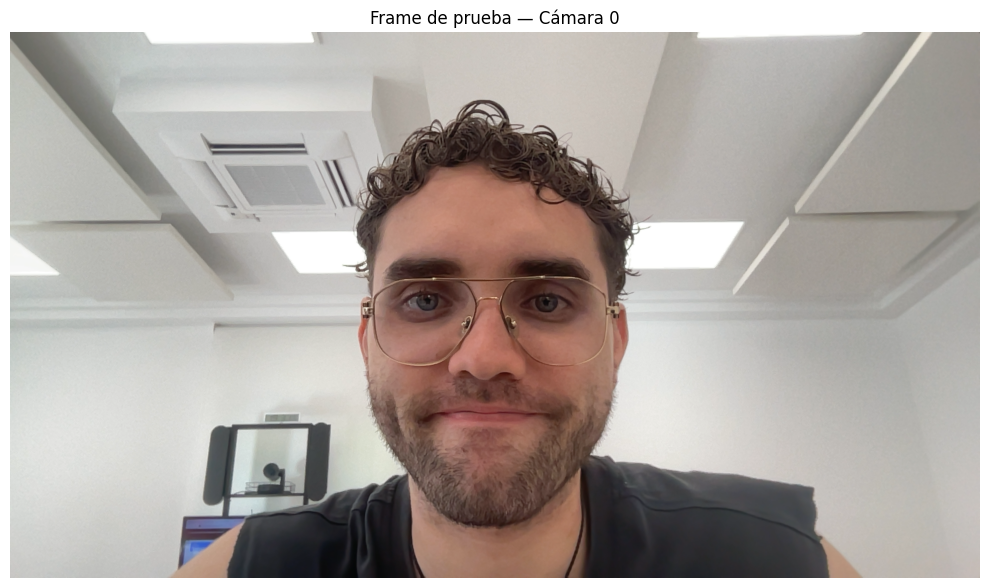

In [17]:
# convierto BGR a RGB para mostrarlo bien en matplotlib
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("Frame de prueba — Cámara 0")
plt.axis("off")
plt.tight_layout()
plt.show()

# Test de Caras con YOLO

## Descagar el Modelo de Caras manualmente para su uso
URL descarga: https://github.com/akanametov/yolo-face/tree/dev

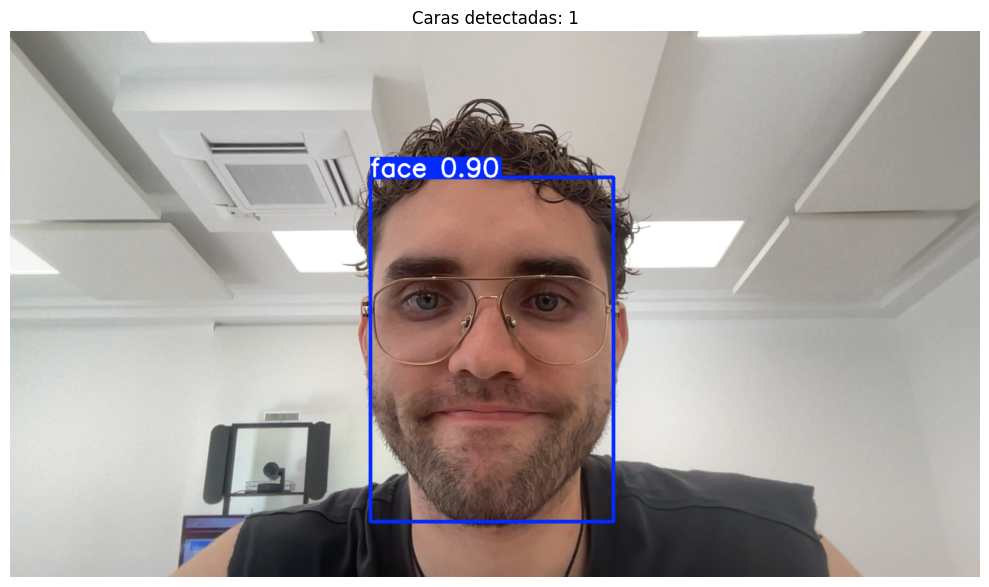

✅ Caras encontradas: 1
   Cara 1 — Confianza: 0.90


In [23]:
# pruebo que YOLOv8-face detecta caras en el frame que capturé
from ultralytics import YOLO

# uso del modelo
model = YOLO("models/yolov12n-face.pt")

resultados = model(frame, verbose=False)

# dibujo los bounding boxes en el frame
frame_detectado = resultados[0].plot()
frame_detectado_rgb = cv2.cvtColor(frame_detectado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_detectado_rgb)
plt.title(f"Caras detectadas: {len(resultados[0].boxes)}")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"✅ Caras encontradas: {len(resultados[0].boxes)}")
for i, box in enumerate(resultados[0].boxes):
    print(f"   Cara {i+1} — Confianza: {box.conf.item():.2f}")

In [24]:
# creamos todas las carpetas que se necesitan en los siguientes notebooks
carpetas = [
    "whitelist",
    "alerts_log",
    "models",
    "src",
    "test_images",
]

for carpeta in carpetas:
    Path(carpeta).mkdir(exist_ok=True)
    print(f"📁 {carpeta}/")

print("\n✅ Estructura lista")

📁 whitelist/
📁 alerts_log/
📁 models/
📁 src/
📁 test_images/

✅ Estructura lista
